# Autoencoder Evaluation from CSV Results

This notebook evaluates the AES experiment CSV outputs in `tmp/` using `tls_profiling.evaluation.evaluate_result_csv`, builds a summary table across experiments, and can display the returned figures for each experiment.


### PARAMETERS:


In [1]:
from pathlib import Path

tmp_dir = Path("tmp")
csv_glob = "ae_*.csv"
show_figures = True
sort_metric = "f1"


In [2]:
import sys
sys.path.append('../../src')


,Variant,ClassLabel,FeatureSet,FeatureKey,CsvFile,pr_auc,tpr_at_fpr_0.1pct,tpr_at_fpr_0.2pct,tpr_at_fpr_0.5pct,tpr_at_fpr_1.0pct,tpr_at_fpr_2.5pct,tpr_at_fpr_5.0pct,ks_statistic,mcc,f1
0,Combined AE,malware,FULL,full,ae_combined_malware_full.csv,0.657638,0.002179,0.002767,0.008933,0.008933,0.008950,0.008950,0.404089,0.027583,0.004348
1,Combined AE,system,FULL,full,ae_combined_system_full.csv,0.964464,0.024228,0.086857,0.444523,0.541618,0.668729,0.698261,0.842363,0.005984,0.002103
2,Combined AE,application,FULL,full,ae_combined_application_full.csv,0.985576,0.000000,0.000014,0.000028,0.000033,0.000043,0.000237,0.156526,-0.030610,0.000028


Evaluated 3 CSV files from /home/rysavy/devel/GitHub/AutoFedProfile/notebooks/aes/tmp


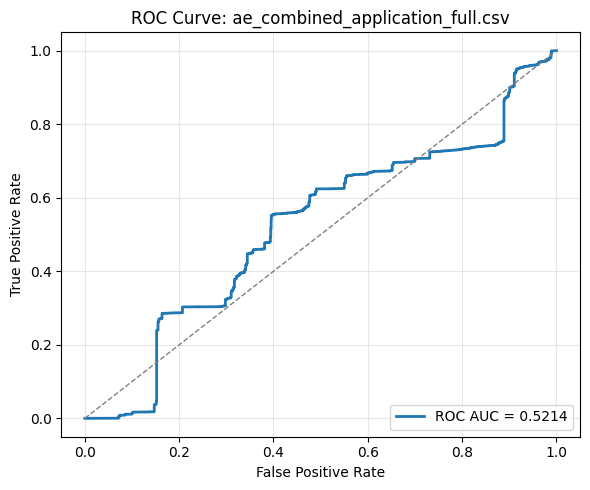

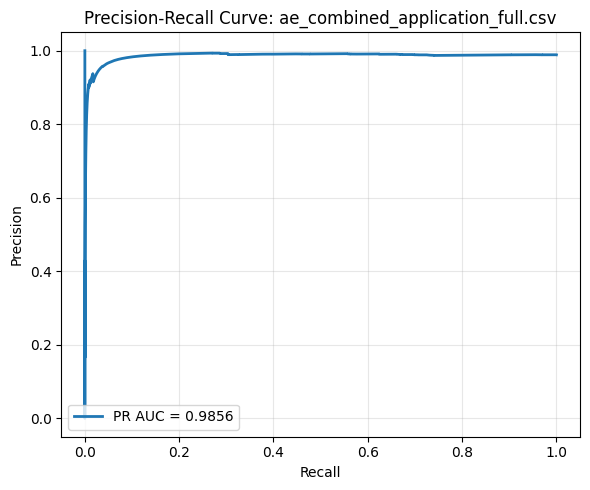

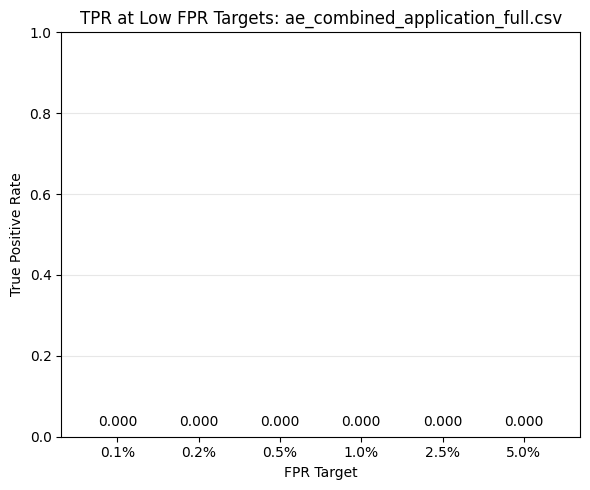

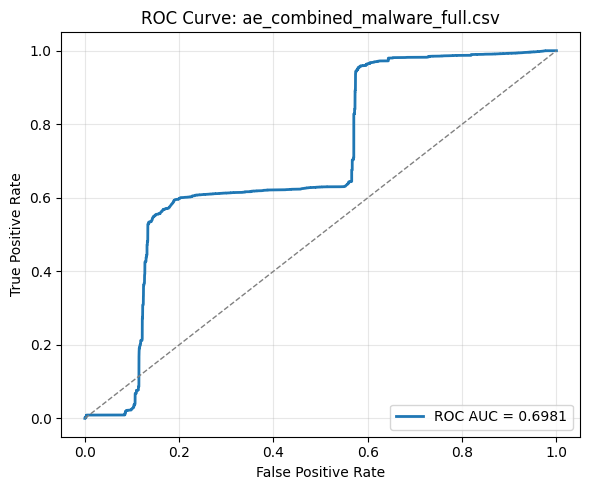

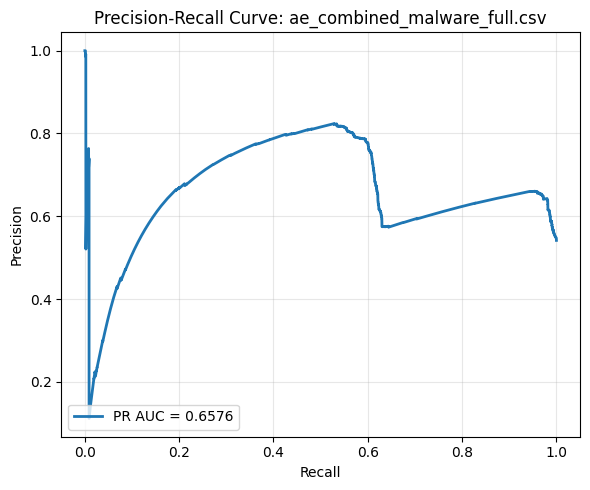

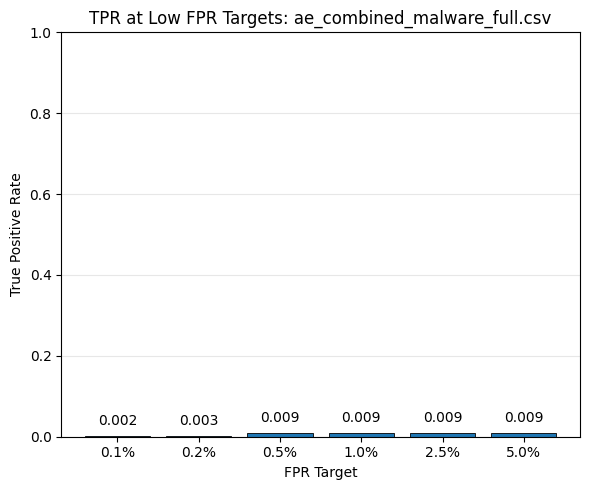

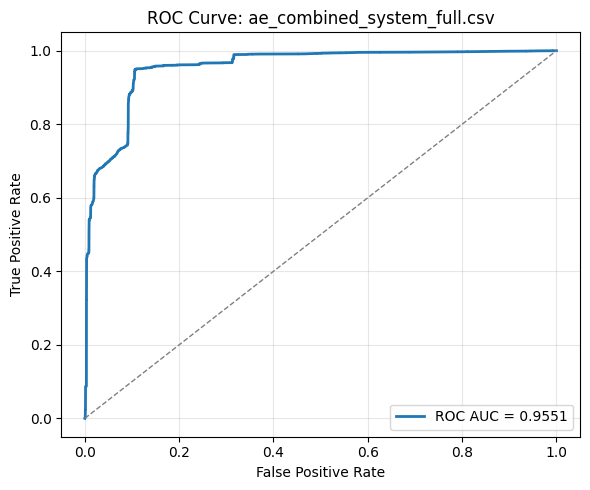

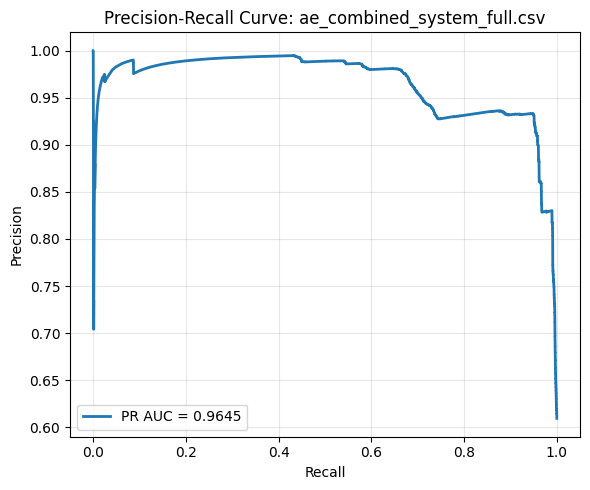

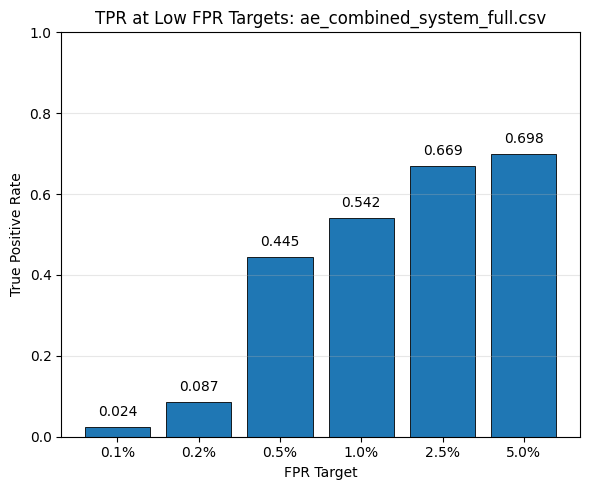

In [3]:
from itertools import combinations

import pandas as pd
from IPython.display import Markdown, display

from tls_profiling.evaluation import evaluate_result_csv

FEATURE_GROUPS = {
    "FLOW": ["bs", "ps", "br", "pr", "td"],
    "CTLS": ["tls.cver", "tls.ccs", "tls.cext", "tls.csg", "tls.alpn", "tls.csv"],
    "STLS": ["tls.sver", "tls.scs", "tls.sext", "tls.ssv"],
    "REC": ["tls.rec"],
}

FEATURE_SET_LOOKUP = {("full",): "FULL"}
group_names = list(FEATURE_GROUPS)
for size in range(1, len(group_names) + 1):
    for group_combo in combinations(group_names, size):
        feature_tokens = []
        for group_name in group_combo:
            feature_tokens.extend(FEATURE_GROUPS[group_name])
        FEATURE_SET_LOOKUP[tuple(feature_tokens)] = " + ".join(group_combo)

def format_feature_set(feature_key: str) -> str:
    tokens = tuple(feature_key.split("_"))
    return FEATURE_SET_LOOKUP.get(tokens, feature_key.replace("_", ", "))

def parse_experiment(csv_path: Path) -> dict:
    file_name = csv_path.name[:-4] if csv_path.name.endswith(".csv") else csv_path.name
    if not file_name.startswith("ae_"):
        raise ValueError(f"Unsupported file name: {csv_path.name}")

    remainder = file_name[len("ae_"):]
    if remainder.startswith("combined_"):
        variant = "Combined AE"
        remainder = remainder[len("combined_"):]
    else:
        variant = "AE"

    class_label, feature_key = remainder.split("_", 1)
    return {
        "Variant": variant,
        "ClassLabel": class_label,
        "FeatureSet": format_feature_set(feature_key),
        "FeatureKey": feature_key,
    }

csv_files = sorted(tmp_dir.glob(csv_glob))
if not csv_files:
    raise FileNotFoundError(f"No CSV files matching {csv_glob!r} found in {tmp_dir.resolve()}")

rows = []
evaluation_outputs = []
for csv_path in csv_files:
    metrics_df, figures = evaluate_result_csv(csv_path)
    metric_values = metrics_df.set_index("metric")["value"].to_dict()
    meta = parse_experiment(csv_path)

    rows.append({
        **meta,
        "CsvFile": csv_path.name,
        **metric_values,
    })
    evaluation_outputs.append({
        **meta,
        "CsvFile": csv_path.name,
        "metrics_df": metrics_df,
        "figures": figures,
    })

summary_df = pd.DataFrame(rows)
if sort_metric in summary_df.columns:
    summary_df = summary_df.sort_values(sort_metric, ascending=False).reset_index(drop=True)

display(summary_df)
print(f"Evaluated {len(summary_df)} CSV files from {tmp_dir.resolve()}")


## Figures

This section displays the figures returned by `evaluate_result_csv(...)` for each experiment.


### Combined AE | application | FULL  
`ae_combined_application_full.csv`

,metric,value
0,pr_auc,0.985576
1,tpr_at_fpr_0.1pct,0.000000
2,tpr_at_fpr_0.2pct,0.000014
3,tpr_at_fpr_0.5pct,0.000028
4,tpr_at_fpr_1.0pct,0.000033
5,tpr_at_fpr_2.5pct,0.000043
6,tpr_at_fpr_5.0pct,0.000237
7,ks_statistic,0.156526
8,mcc,0.000000
9,f1,0.994414


**roc_curve**

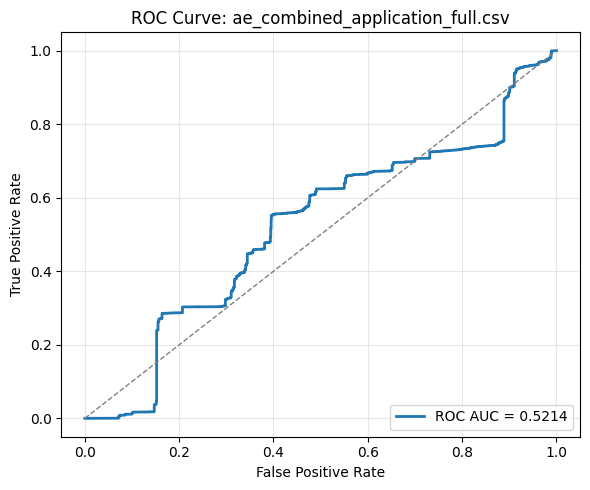

**pr_curve**

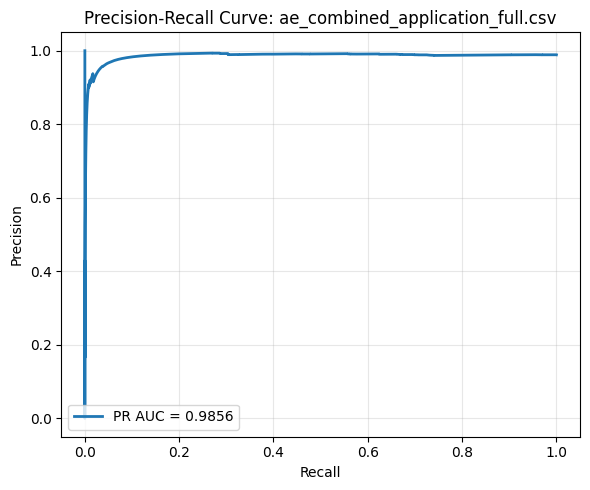

**tpr_at_low_fpr**

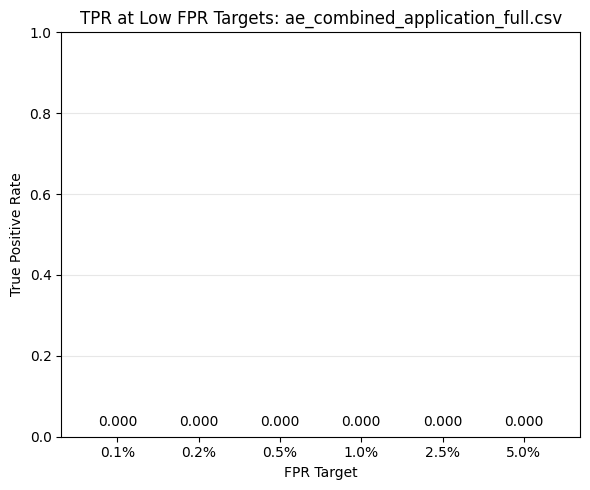

### Combined AE | malware | FULL  
`ae_combined_malware_full.csv`

,metric,value
0,pr_auc,0.657638
1,tpr_at_fpr_0.1pct,0.002179
2,tpr_at_fpr_0.2pct,0.002767
3,tpr_at_fpr_0.5pct,0.008933
4,tpr_at_fpr_1.0pct,0.008933
5,tpr_at_fpr_2.5pct,0.008950
6,tpr_at_fpr_5.0pct,0.008950
7,ks_statistic,0.404089
8,mcc,0.449366
9,f1,0.779363


**roc_curve**

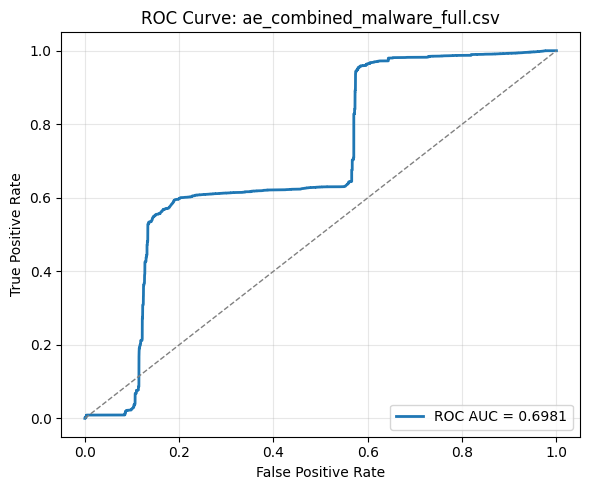

**pr_curve**

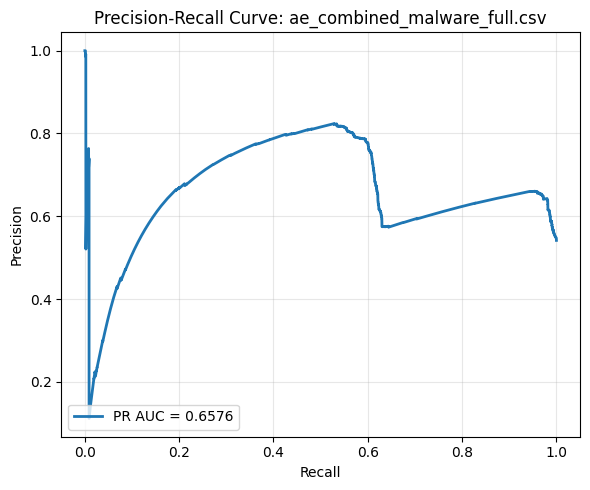

**tpr_at_low_fpr**

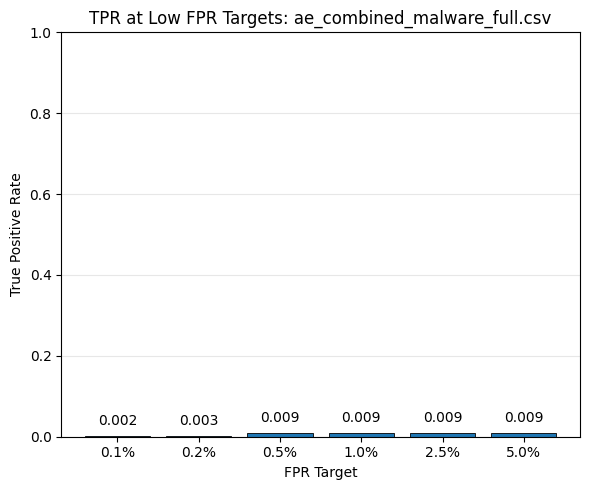

### Combined AE | system | FULL  
`ae_combined_system_full.csv`

,metric,value
0,pr_auc,0.964464
1,tpr_at_fpr_0.1pct,0.024228
2,tpr_at_fpr_0.2pct,0.086857
3,tpr_at_fpr_0.5pct,0.444523
4,tpr_at_fpr_1.0pct,0.541618
5,tpr_at_fpr_2.5pct,0.668729
6,tpr_at_fpr_5.0pct,0.698261
7,ks_statistic,0.842363
8,mcc,0.846550
9,f1,0.940910


**roc_curve**

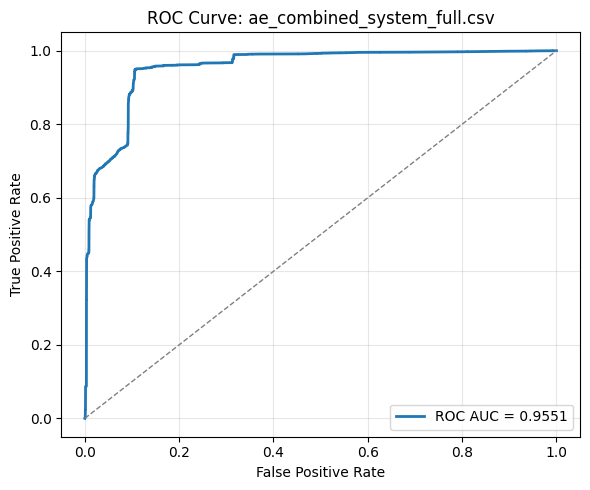

**pr_curve**

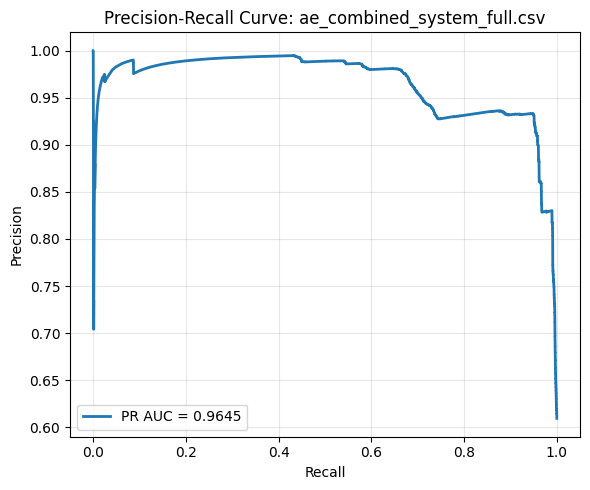

**tpr_at_low_fpr**

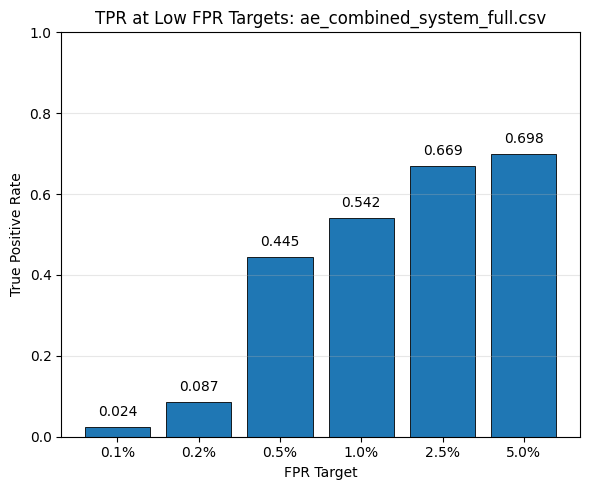

In [4]:
if show_figures:
    for result in evaluation_outputs:
        display(Markdown(
            f"### {result['Variant']} | {result['ClassLabel']} | {result['FeatureSet']}  \n"
            f"`{result['CsvFile']}`"
        ))
        display(result['metrics_df'])
        for figure_name, figure in result['figures'].items():
            display(Markdown(f"**{figure_name}**"))
            display(figure)
